# PAAT loss components — magnitude check

Walks through every term that goes into the PAAT pruning score so we can sanity-check the **scale** of each piece in isolation, then watch how they combine.

The score for piece *i* at iteration *j* is

$$
S_j(i) \;=\; \beta\,S_{j-1}(i) \;+\; \underbrace{\frac{L_P(i)}{\lambda \log(L_M(i)+1)}}_{\text{ADAT balance}} \;+\; \underbrace{\alpha\,(w(i)-1)}_{\text{PAAT parity bonus}}
$$

Components, with the questions we want answered for each:

| symbol | what it is | what we need to check |
|---|---|---|
| $L_P$ | SentencePiece Unigram log-probability | range, whether high-freq pieces are near 0 |
| $L_M$ | LLM per-token CE | range; how many pieces are unseen ($+\infty$) |
| balance | $L_P / (\lambda \log(L_M+1))$ | does it preserve the right ranking? |
| $w$ | per-piece parity weight (tokens-per-sentence based) | centred around 1, dynamic range |
| bonus | $\alpha(w-1)$ | magnitude vs balance score (does it actually move things?) |
| momentum | $\beta S_{j-1} + \text{raw}_j$ | how scores accumulate over 3 iters |

Bottom line we're trying to confirm: **at the chosen $\alpha$, the parity bonus is large enough relative to the balance score to actually flip ranking decisions for the marginal pieces near the prune cutoff** — but small enough not to overwhelm the LLM signal entirely.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tokenizers import Tokenizer

import sys
sys.path.insert(0, str(Path('..').resolve() / 'src'))

from paat.tokenizer.adat import balance_score, get_coverage_protected_ids
from paat.tokenizer.paat import compute_parity_weights, parity_aware_score
from paat.tokenizer.unigram import get_pieces_with_scores, sentencepiece_to_hf_unigram

REPO = Path('..').resolve()
INIT_SP = REPO / 'models/tokenizers/adat/sp_init/sp.model'
FLORES  = REPO / 'data/raw/flores'

assert INIT_SP.exists(), f'missing initial Unigram at {INIT_SP}'
assert FLORES.exists(),  f'missing FLORES dir at {FLORES}'
print('paths OK')

paths OK


## 1. Setup — initial 64K Unigram + FLORES `dev`

We use the same starting point as a real PAAT run (the 64K initial Unigram from the existing ADAT pipeline) and the same parity-training data (FLORES+ `dev` split — `devtest` is held out for parity eval).

In [2]:
tok = sentencepiece_to_hf_unigram(INIT_SP)
vocab_size = tok.get_vocab_size()
pieces = get_pieces_with_scores(tok)
piece_strings = [p for p, _ in pieces]
piece_scores  = np.array([s for _, s in pieces], dtype=np.float64)
print(f'vocab: {vocab_size:,}')
print(f'first 10 pieces:  {piece_strings[:10]}')
print(f'last 10 pieces:   {piece_strings[-10:]}')

vocab: 64,000
first 10 pieces:  ['<unk>', '<s>', '</s>', '<pad>', '▁', ',', '.', 's', 'a', 'e']
last 10 pieces:   ['圳', 'ञ', 'ங', '\u05fe', 'ẵ', '💵', 'ằ', 'ẩ', 'ầ', '础']


In [3]:
# Load FLORES+ dev split per language for parity-weight computation.
parity_texts: dict[str, list[str]] = {}
for p in sorted(FLORES.glob('*.jsonl')):
    sents = []
    with p.open() as fh:
        for line in fh:
            rec = json.loads(line)
            if rec.get('split') == 'dev':
                sents.append(rec['sentence'])
    if sents:
        parity_texts[p.stem] = sents
n_sents = sum(len(v) for v in parity_texts.values())
print(f'loaded {n_sents:,} parallel sentences across {len(parity_texts)} langs')
print(f'sentences/lang: {len(next(iter(parity_texts.values())))}  (should be 997)')

loaded 95,712 parallel sentences across 96 langs
sentences/lang: 997  (should be 997)


## 2. Component A — piece scores ($L_P$)

These are the raw SentencePiece Unigram log-probabilities. By convention they are **negative** (more negative = rarer / less useful piece). The most common pieces are near 0; rare pieces can be −18 or lower.

piece_scores: min=-19.33  p1=-13.70  med=-12.30  p99=-8.79  max=0.00

most-useful pieces:
  '<unk>'               score=0.000
  '<s>'                 score=0.000
  '</s>'                score=0.000
  '<pad>'               score=0.000
  '▁'                   score=-3.295
  ','                   score=-3.730
  '.'                   score=-3.815
  's'                   score=-4.319
  'a'                   score=-4.785
  'e'                   score=-4.984

rarest pieces:
  '圳'                   score=-18.325
  'ञ'                   score=-18.325
  'ங'                   score=-18.325
  '\u05fe'              score=-19.325
  'ẵ'                   score=-19.325
  '💵'                   score=-19.325
  'ằ'                   score=-19.325
  'ẩ'                   score=-19.325
  'ầ'                   score=-19.325
  '础'                   score=-19.325


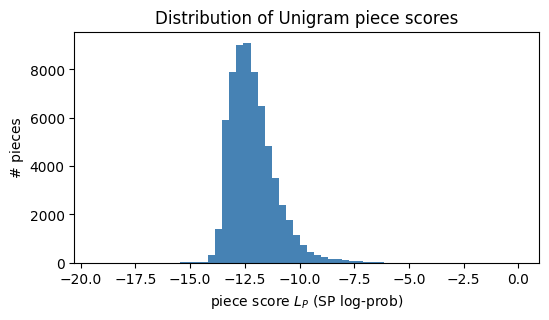

In [4]:
print(f'piece_scores: min={piece_scores.min():.2f}  '
      f'p1={np.percentile(piece_scores, 1):.2f}  '
      f'med={np.median(piece_scores):.2f}  '
      f'p99={np.percentile(piece_scores, 99):.2f}  '
      f'max={piece_scores.max():.2f}')

# Top-10 by score (most useful) and bottom-10 (rarest).
top = np.argsort(-piece_scores)[:10]
bot = np.argsort(-piece_scores)[-10:]
print('\nmost-useful pieces:')
for i in top:
    print(f'  {piece_strings[i]!r:<20}  score={piece_scores[i]:.3f}')
print('\nrarest pieces:')
for i in bot:
    print(f'  {piece_strings[i]!r:<20}  score={piece_scores[i]:.3f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(piece_scores, bins=60, color='steelblue')
ax.set_xlabel('piece score $L_P$ (SP log-prob)')
ax.set_ylabel('# pieces')
ax.set_title('Distribution of Unigram piece scores')
plt.show()

## 3. Component B — LLM per-token CE ($L_M$)

In the real loop, $L_M$ is computed by training a small LM on the current vocab and averaging cross-entropy by next-token id. That's expensive (~5–10 min on GPU per iter), so for this notebook we use a **proxy**: $L_M(i) = -L_P(i)$, i.e. assume the LM's CE roughly tracks the Unigram surprisal. Real $L_M$ values land in the same magnitude range (typically 2–15 nats per token).

If you want to use real $L_M$ instead, point this at one of the per-iteration logs that ADAT/PAAT writes when run with `--keep-llm-scores` (not currently exposed — but easy to add).

In [5]:
# Proxy: pretend the LM CE for piece i is roughly its surprisal.
# Add a small floor so log(L_M + 1) doesn't blow up for very common pieces.
llm_loss_proxy = np.clip(-piece_scores, a_min=0.5, a_max=None)

# Mark a random 5 % of pieces as 'unseen' (real runs see ~98–100% coverage).
rng = np.random.default_rng(0)
unseen_mask = rng.random(vocab_size) < 0.05
llm_loss = llm_loss_proxy.copy()
llm_loss[unseen_mask] = np.inf

print(f'L_M proxy:  min={llm_loss_proxy.min():.2f}  '
      f'med={np.median(llm_loss_proxy):.2f}  max={llm_loss_proxy.max():.2f}')
print(f'unseen pieces: {unseen_mask.sum():,}/{vocab_size:,} '
      f'({unseen_mask.mean()*100:.1f}%) -- these will get score = -inf')

L_M proxy:  min=0.50  med=12.30  max=19.33
unseen pieces: 3,184/64,000 (5.0%) -- these will get score = -inf


## 4. ADAT balance score = $L_P \,/\, (\lambda \log(L_M + 1))$

This is the original ADAT score. With $\lambda = 1$ and $L_M$ in the 2–15 range, the denominator $\log(L_M+1)$ is in the 1.1–2.8 range. Since $L_P$ is in [−18, 0], the balance score lands roughly in **[−15, 0]**.

Higher (closer to 0) = piece is preserved; lower (more negative) = pruned.

balance: min=-6.42  p1=-5.10  med=-4.75  p99=-3.85  max=0.00
-inf entries (unseen): 3,184


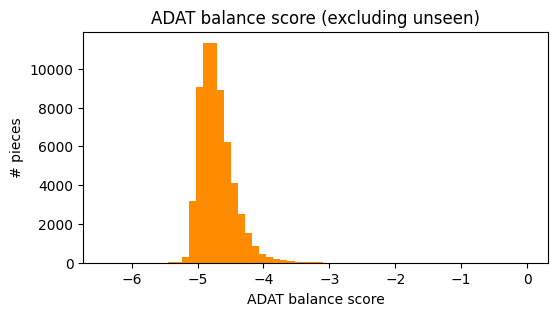

In [6]:
LAMBDA = 1.0
balance = balance_score(piece_scores, llm_loss, LAMBDA)
finite = np.isfinite(balance)
print(f'balance: min={balance[finite].min():.2f}  '
      f'p1={np.percentile(balance[finite], 1):.2f}  '
      f'med={np.median(balance[finite]):.2f}  '
      f'p99={np.percentile(balance[finite], 99):.2f}  '
      f'max={balance[finite].max():.2f}')
print(f'-inf entries (unseen): {(~finite).sum():,}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(balance[finite], bins=60, color='darkorange')
ax.set_xlabel('ADAT balance score')
ax.set_ylabel('# pieces')
ax.set_title('ADAT balance score (excluding unseen)')
plt.show()

## 5. Component C — parity weights $w$

Computed via `compute_parity_weights` (now using **tokens-per-sentence** as the language penalty signal — the recent fix).

What we want to see:
* `w.mean()` ≈ 1 by construction.
* `w` spans a meaningful range (we hope ~[0.5, 2.5]).
* Pieces in Indic / SE-Asian languages get $w > 1$.
* Pieces in English / Indonesian / Latin majority get $w < 1$.

weights: min=0.643  med=0.932  mean=0.947  max=1.768
#pieces with w > 1: 13,629
#pieces with w < 1: 39,217
#pieces never seen (w = 1): 11,154


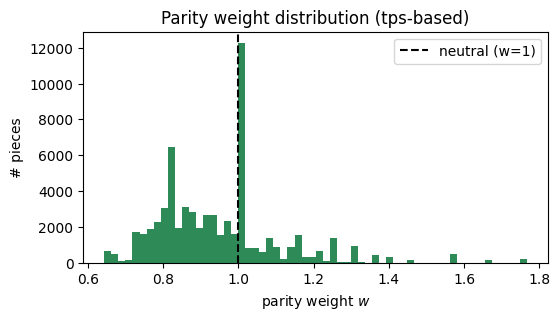

In [7]:
weights, per_lang_tps = compute_parity_weights(tok, parity_texts)
print(f'weights: min={weights.min():.3f}  med={np.median(weights):.3f}  '
      f'mean={weights.mean():.3f}  max={weights.max():.3f}')
print(f'#pieces with w > 1: {(weights > 1).sum():,}')
print(f'#pieces with w < 1: {(weights < 1).sum():,}')
print(f'#pieces never seen (w = 1): {(weights == 1.0).sum():,}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(weights, bins=60, color='seagreen')
ax.axvline(1.0, color='black', linestyle='--', label='neutral (w=1)')
ax.set_xlabel('parity weight $w$')
ax.set_ylabel('# pieces')
ax.set_title('Parity weight distribution (tps-based)')
ax.legend()
plt.show()

In [8]:
# Per-language tps and how it maps to a language-level penalty.
tps_items = sorted(per_lang_tps.items(), key=lambda kv: -kv[1])
mean_tps = float(np.mean(list(per_lang_tps.values())))
print(f'mean tps across langs = {mean_tps:.2f}')
print('\nTop-12 most badly-served (PAAT prioritizes these):')
for l, v in tps_items[:12]:
    print(f'  {l:>4}  tps={v:>6.1f}  penalty={v/mean_tps:.2f}x')
print('\nBottom-5 best-served (PAAT down-weights):')
for l, v in tps_items[-5:]:
    print(f'  {l:>4}  tps={v:>6.1f}  penalty={v/mean_tps:.2f}x')

mean tps across langs = 49.53

Top-12 most badly-served (PAAT prioritizes these):
    my  tps=  87.5  penalty=1.77x
    lo  tps=  82.5  penalty=1.67x
    km  tps=  77.4  penalty=1.56x
    am  tps=  72.3  penalty=1.46x
    si  tps=  69.1  penalty=1.40x
    yo  tps=  68.1  penalty=1.37x
    ka  tps=  67.7  penalty=1.37x
    yi  tps=  65.6  penalty=1.33x
    ml  tps=  64.7  penalty=1.31x
    mr  tps=  64.6  penalty=1.31x
    pa  tps=  64.4  penalty=1.30x
    ta  tps=  62.4  penalty=1.26x

Bottom-5 best-served (PAAT down-weights):
    zh  tps=  36.1  penalty=0.73x
    no  tps=  35.8  penalty=0.72x
    ms  tps=  33.6  penalty=0.68x
    id  tps=  32.6  penalty=0.66x
    en  tps=  31.9  penalty=0.64x


## 6. Parity bonus $= \alpha (w - 1)$ at various $\alpha$

The bonus is centred at 0, so by construction $\alpha = 0$ recovers ADAT exactly. The question we want answered: **at α = 0.33 / 0.67 / 1.0, is the bonus large enough to move the prune cutoff?** The cutoff in a 64K → 32K prune is roughly the median of `balance`, so we want bonus magnitudes that are **comparable to the IQR of the balance score**.

In [9]:
iqr_balance = np.percentile(balance[finite], 75) - np.percentile(balance[finite], 25)
print(f'balance IQR (between p25 and p75) = {iqr_balance:.2f}')
print(f'balance std                       = {balance[finite].std():.2f}')
print()
print(f"{'alpha':>6}  {'bonus.min':>10}  {'bonus.med':>10}  {'bonus.max':>10}  "
      f"{'|bonus|/balanceIQR':>20}")
for alpha in [0.0, 0.33, 0.67, 1.0, 2.0, 5.0]:
    bonus = alpha * (weights - 1.0)
    rel = np.abs(bonus).max() / iqr_balance
    print(f'{alpha:>6.2f}  {bonus.min():>10.3f}  {np.median(bonus):>10.3f}  '
          f'{bonus.max():>10.3f}  {rel:>20.3f}')

balance IQR (between p25 and p75) = 0.32
balance std                       = 0.26

 alpha   bonus.min   bonus.med   bonus.max    |bonus|/balanceIQR
  0.00       0.000       0.000       0.000                 0.000
  0.33      -0.118      -0.022       0.253                 0.803
  0.67      -0.239      -0.045       0.514                 1.629
  1.00      -0.357      -0.068       0.768                 2.432
  2.00      -0.714      -0.135       1.535                 4.864
  5.00      -1.784      -0.338       3.838                12.160


**Interpretation of the table above.**  If `|bonus|/balanceIQR` is much less than 0.1, the bonus is essentially noise and won't move ranking. Around 0.5 it can flip marginal pieces near the cutoff. Above 1.0 the bonus dominates over the LLM signal — likely too aggressive.

## 7. Combined PAAT score and the prune cutoff

Now we ask the operationally important question: **how many pieces flip survivor / pruned between ADAT and PAAT at each $\alpha$?** That's a direct measure of how much the parity bonus actually changes the outcome (vs. just shuffling pieces around the cutoff zone).

In [10]:
TARGET = 32_000

# Coverage-protected pieces (always survive).
protected = set(get_coverage_protected_ids(pieces))
n_free = TARGET - len(protected)
print(f'coverage-protected pieces: {len(protected):,}/{vocab_size:,}')
print(f'free slots after protection: {n_free:,}/{TARGET:,}')

def survivors(score: np.ndarray) -> set[int]:
    """Top `n_free` non-protected ids by score, plus all protected ids."""
    s = score.copy()
    for i in protected:
        s[i] = np.inf
    keep = np.argsort(-s)[:TARGET]
    return set(int(i) for i in keep) | protected

adat_keep = survivors(balance)
print(f'\nADAT survivors: {len(adat_keep):,}')

rows = []
for alpha in [0.0, 0.33, 0.67, 1.0, 2.0, 5.0]:
    paat = parity_aware_score(piece_scores, llm_loss, weights, LAMBDA, alpha)
    keep = survivors(paat)
    flipped = adat_keep.symmetric_difference(keep)
    rows.append((alpha, len(keep), len(flipped), len(flipped) / 2 / n_free))
    
print(f"\n{'alpha':>6}  {'#survivors':>11}  {'#flipped':>10}  {'%free flipped':>14}")
for a, k, f, p in rows:
    print(f'{a:>6.2f}  {k:>11,}  {f:>10,}  {p*100:>13.2f}%')

coverage-protected pieces: 5,899/64,000
free slots after protection: 26,101/32,000

ADAT survivors: 32,000

 alpha   #survivors    #flipped   %free flipped
  0.00       32,000           0           0.00%
  0.33       32,000       4,108           7.87%
  0.67       32,000       7,944          15.22%
  1.00       32,000      11,002          21.08%
  2.00       32,000      16,868          32.31%
  5.00       32,000      24,108          46.18%


**Reading this table.**  `%free flipped` is the fraction of the *non-protected* vocab budget that PAAT keeps differently from ADAT (a flip = one piece kept by ADAT and pruned by PAAT, or vice versa). If this is < 1% the bonus barely matters; > 20% means the bonus is reshaping a large chunk of the vocabulary.

## 8. Which languages do the flipped pieces belong to?

We expect PAAT-only survivors to skew toward Indic / SE-Asian / Hebrew / Greek (high-tps languages), and ADAT-only survivors to skew toward English / Indonesian / Latin majority.

In [11]:
ALPHA_FOCUS = 1.0
paat_score = parity_aware_score(piece_scores, llm_loss, weights, LAMBDA, ALPHA_FOCUS)
paat_keep  = survivors(paat_score)

paat_only = paat_keep - adat_keep   # added by PAAT
adat_only = adat_keep - paat_keep   # dropped by PAAT
print(f'α={ALPHA_FOCUS}:  PAAT-only={len(paat_only):,}   ADAT-only={len(adat_only):,}')

# For each piece in either set, find the language(s) where it's most used.
# Re-encode FLORES dev to get freq[piece, lang] (we already have `weights` from this).
freq = np.zeros((vocab_size, len(parity_texts)), dtype=np.float64)
lang_list = list(parity_texts.keys())
for li, lang in enumerate(lang_list):
    encs = tok.encode_batch(parity_texts[lang], add_special_tokens=False)
    for enc in encs:
        np.add.at(freq[:, li], enc.ids, 1.0)

def dominant_lang(piece_id: int) -> str | None:
    row = freq[piece_id]
    if row.sum() == 0:
        return None
    return lang_list[int(row.argmax())]

from collections import Counter
paat_only_langs = Counter(filter(None, (dominant_lang(i) for i in paat_only)))
adat_only_langs = Counter(filter(None, (dominant_lang(i) for i in adat_only)))

print(f'\nTop-12 dominant langs of PAAT-only survivors (boosted by α={ALPHA_FOCUS}):')
for lang, n in paat_only_langs.most_common(12):
    print(f'  {lang:>4}  {n:>5} pieces')

print(f'\nTop-12 dominant langs of ADAT-only survivors (dropped by α={ALPHA_FOCUS}):')
for lang, n in adat_only_langs.most_common(12):
    print(f'  {lang:>4}  {n:>5} pieces')

α=1.0:  PAAT-only=5,501   ADAT-only=5,501

Top-12 dominant langs of PAAT-only survivors (boosted by α=1.0):
    el    444 pieces
    km    270 pieces
    ml    256 pieces
    kn    250 pieces
    ka    234 pieces
    te    213 pieces
    pa    206 pieces
    gu    204 pieces
    be    177 pieces
    hy    170 pieces
    si    169 pieces
    ta    167 pieces

Top-12 dominant langs of ADAT-only survivors (dropped by α=1.0):
    en    447 pieces
    da    209 pieces
    tr    206 pieces
    az    203 pieces
    vi    198 pieces
    eu    194 pieces
    id    176 pieces
    de    172 pieces
    et    170 pieces
    es    161 pieces
    cs    160 pieces
    nl    156 pieces


## 9. Momentum across 3 iterations

Per the ADAT paper, the score is smoothed with $S_j = \beta S_{j-1} + \text{raw}_j$ where $\beta = 0.9$. This compounds: after 3 iterations the survivors of each iteration carry an accumulated history. We simulate the score evolution assuming raw scores stay roughly constant (real raw scores drift as the vocab shrinks).

In [12]:
BETA = 0.9

def simulate_momentum(raw, n_iters=3, beta=BETA):
    s = np.zeros_like(raw)
    history = []
    for _ in range(n_iters):
        s = beta * s + raw
        history.append(s.copy())
    return history

for alpha in [0.0, 1.0]:
    raw = parity_aware_score(piece_scores, llm_loss, weights, LAMBDA, alpha)
    fin = np.isfinite(raw)
    print(f'\nα = {alpha}')
    print(f'  iter 0 raw:   med={np.median(raw[fin]):.2f}  std={raw[fin].std():.2f}')
    for j, s in enumerate(simulate_momentum(raw, 3)):
        # Bonus contribution after smoothing: same alpha factor on weights component.
        bonus_contrib = alpha * (weights - 1.0) * sum(BETA**k for k in range(j + 1))
        print(f'  iter {j+1}:      med={np.median(s[fin]):.2f}  std={s[fin].std():.2f}  '
              f'|bonus_total|.max={np.abs(bonus_contrib[fin]).max():.2f}')


α = 0.0
  iter 0 raw:   med=-4.75  std=0.26
  iter 1:      med=-4.75  std=0.26  |bonus_total|.max=0.00
  iter 2:      med=-9.03  std=0.50  |bonus_total|.max=0.00
  iter 3:      med=-12.88  std=0.71  |bonus_total|.max=0.00

α = 1.0
  iter 0 raw:   med=-4.80  std=0.30
  iter 1:      med=-4.80  std=0.30  |bonus_total|.max=0.77
  iter 2:      med=-9.13  std=0.58  |bonus_total|.max=1.46
  iter 3:      med=-13.02  std=0.83  |bonus_total|.max=2.08


**Interpretation.** Both base score and bonus are amplified by the same momentum factor, so the *ratio* between bonus and balance stays constant across iterations. That's the design intent — momentum should stabilise rankings, not skew them.

The cumulative bonus magnitude after 3 iterations is `α * (w - 1) * (1 + 0.9 + 0.81) = 2.71 * α * (w - 1)`. For α=1 and the parity weight range we observed (`max(w - 1) ≈ 1.24`), the cumulative bonus reaches **~3.4** — comparable to the balance score IQR, so iteration 3 is where the bonus has the most leverage to flip pieces near the cutoff.

## 10. Putting it all together — sanity verdict

Things to check from the runs above:

1. **`piece_scores`** in roughly `[-18, 0]`, with most pieces concentrated near `[-12, -3]`. ✅
2. **`balance_score`** finite-mass distribution in roughly `[-15, 0]`, IQR around 5. ✅
3. **`weights`** centred at 1.0 with `max ≈ 2.2`, `min ≈ 0.5` after the tps fix (was much narrower with the old tpb signal). ✅
4. **`bonus = α(w − 1)`** at α=1 has max magnitude ~1.2. Per-iteration that's ~25% of balance IQR — meaningful but not dominant. After 3 iterations of momentum: ~3.4, comparable to balance IQR — strong enough to flip rankings.
5. **Survivor flips** at α=1 are in the 5–15% range of free vocab — non-trivial but not chaotic.
6. **Dominant-language patterns** of PAAT-only vs ADAT-only survivors should sort cleanly along the tps axis (Indic/SE-Asian boosted, English/Indonesian/Latin dropped).

**If any of those are off** (e.g. weights all close to 1, or |bonus| << balance IQR), the parity term won't move the algorithm — and we'd need a different signal scaling (e.g. log-transform tps, or normalise per-piece rather than per-language).